In [1]:
import random
import math
import matplotlib.pyplot as plt

In [17]:
class KMeans:
    def __init__(self, X, k, epochs=100, c=random.sample(X, k)):
        self.epochs = epochs
        self.k = k
        self.X = X
        self.centers = c

    def euclidean_distance(self, x1, x2):
        return math.sqrt(sum((a - b) ** 2 for a, b in zip(x1, x2))) # евклидово расстояние
    
    def assign_clusters(self):
        clusters = {i: [] for i in range(self.k)} # создание пустых массивов н-го кол-ва
        for x in self.X:
            distances = [self.euclidean_distance(x, center) for center in self.centers] # дист. до всех центров от х
            cluster_idx = distances.index(min(distances)) # мин дист
            clusters[cluster_idx].append(x) # занесение в кластер
        return clusters
    
    def update_centers(self, clusters):
        new_centers = []
        for i in range(self.k):
            if clusters[i]:
                new_center = [sum(dim) / len(clusters[i]) for dim in zip(*clusters[i])] # сум х/н
                new_centers.append(new_center)
            else:
                new_centers.append(self.centers[i])
        return new_centers
    
    def fit(self):
        for _ in range(self.epochs):
            clusters = self.assign_clusters() # кластеризация
            new_centers = self.update_centers(clusters) # обновление центров
            if new_centers == self.centers: # стоп при повторении центров
                break
            self.centers = new_centers # установление нов центров
        return self.centers, clusters

In [14]:
k = int(input())
X = []
for i in range(k):
    X.append(list(map(int, input().split())))
k = int(input())
c = []
for i in range(k):
    c.append(list(map(int, input().split())))

kmeans = KMeans(X, k=k, epochs=100, c=c)
centers, clusters = kmeans.fit()

 5
 -1 1
 -1 2
 -2 1
 1 0
 2 0
 2
 -2 2
 3 0


In [15]:
for x in centers:
    print(x[0], x[1])

-1.3333333333333333 1.3333333333333333
1.5 0.0


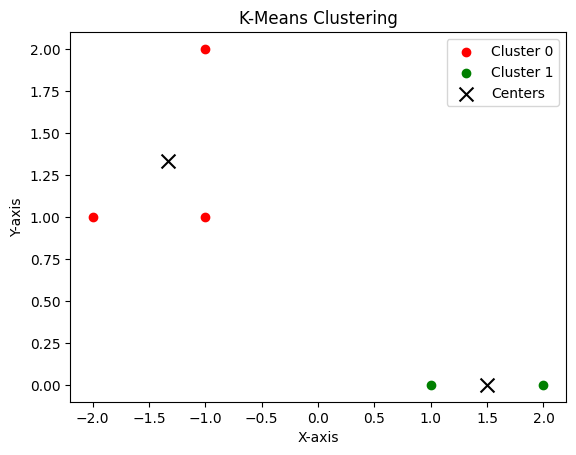

In [16]:
colors = ['r', 'g', 'b']
for i, cluster in clusters.items():
    cluster_points = list(zip(*cluster))
    plt.scatter(cluster_points[0], cluster_points[1], color=colors[i], label=f'Cluster {i}')

centers_points = list(zip(*centers))
plt.scatter(centers_points[0], centers_points[1], color='black', marker='x', s=100, label='Centers')
plt.legend()
plt.xlabel('X-axis')
plt.ylabel('Y-axis')
plt.title('K-Means Clustering')
plt.show()